# Replenishment Workflow Analysis

This notebook analyses the replenishment workflow of the spare-parts warehouse.

The objective is to evaluate:
- reorder-point exposure
- ERP/WMS replenishment suggestions
- purchase requisition workload
- supplier and lead-time exposure
- replenishment priority structure
- planner exception flags
- operational replenishment risk

The analyses support ERP/WMS-style replenishment monitoring, purchase requisition review, and operational inventory-control decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("../outputs/as_is_workflows")
OUTPUT_DIR.mkdir(exist_ok=True)

part_master = pd.read_csv("../data/part_master.csv")
inventory_status = pd.read_csv("../data/inventory_status.csv")
supplier_master = pd.read_csv("../data/supplier_master.csv")
purchase_requisitions = pd.read_csv("../data/purchase_requisitions.csv")

## Replenishment Workflow Dataset

The replenishment workflow analysis combines material master data, current inventory position, supplier lead-time performance, and purchase requisition records.

The workflow logic focuses on analysing ERP/WMS replenishment outputs, stock-position exposure, and purchase requisition workload.

In [3]:
# Combine master, inventory, supplier, and ERP/WMS replenishment outputs
replenishment = (
    part_master
    .merge(inventory_status, on="Part_ID", how="left", suffixes=("", "_Inventory"))
    .merge(
        supplier_master[[
            "Supplier_ID",
            "Supplier_Name",
            "Avg_Lead_Time_Days",
            "Lead_Time_SD_Days",
            "Reliability_Score"
        ]],
        on="Supplier_ID",
        how="left"
    )
)

replenishment["Below_Reorder_Point"] = (
    replenishment["Available_Qty"] <=
    replenishment["Reorder_Point_Qty"]
)

# Estimate stock exposure after considering open orders
replenishment["Projected_Available_Qty"] = (
    replenishment["Available_Qty"] +
    replenishment["On_Order_Qty"]
)

replenishment["Projected_Below_Reorder_Point"] = (
    replenishment["Projected_Available_Qty"] <=
    replenishment["Reorder_Point_Qty"]
)

replenishment["Stock_Gap_To_Reorder_Point"] = (
    replenishment["Reorder_Point_Qty"] -
    replenishment["Available_Qty"]
).clip(lower=0)

# Convert ERP/WMS suggested quantity into estimated replenishment value
replenishment["Suggested_Replenishment_Value_EUR"] = (
    replenishment["Suggested_Replenishment_Qty"] *
    replenishment["Unit_Cost_EUR"]
)

replenishment["Stock_Coverage_Weeks"] = np.where(
    replenishment["Avg_Weekly_Demand"] > 0,
    replenishment["Available_Qty"] /
    replenishment["Avg_Weekly_Demand"],
    np.nan
)

replenishment["Lead_Time_Coverage_Gap_Weeks"] = (
    replenishment["Lead_Time_Weeks"] -
    replenishment["Stock_Coverage_Weeks"]
)

replenishment.head()

,Part_ID,Part_Name,Equipment_Family_ID,Equipment_Family,Equipment_Model,Part_Category_ID,Part_Category,Demand_Profile,Criticality,Supplier_ID,Supplier_Region,Unit_Cost_EUR,Storage_Type,Lifecycle_Status,Target_Service_Level,Avg_Weekly_Demand_Seed,ABC_Class,Source_Context,Movement_Class,Movement_Lines_36M,Annual_Lines,Avg_Monthly_Lines,Cumulative_Movement_%,Manual_Location,UDC_Type,Dim_X_mm,Dim_Y_mm,Dim_Z_mm,Unit_Volume_cm3,Max_Dimension_mm,Min_Dimension_mm,Stock_Managed,Avg_Daily_Qty,Lead_Time_Weeks,Safety_Stock_Qty,Reorder_Point_Qty,Max_Stock_Qty,Stock_Qty,Total_Qty_36M,Total_Volume_cm3,On_Hand_Qty,On_Order_Qty,Allocated_Qty,Available_Qty,Avg_Weekly_Demand,Demand_SD,Demand_CV,Nonzero_Demand_Weeks,XYZ_Class,Lead_Time_Weeks_Inventory,Safety_Stock_Qty_Inventory,Reorder_Point_Qty_Inventory,Suggested_Replenishment_Qty,Planner_Exception_Flag,Manual_Location_Inventory,UDC_Type_Inventory,Supplier_Name,Avg_Lead_Time_Days,Lead_Time_SD_Days,Reliability_Score,Below_Reorder_Point,Projected_Available_Qty,Projected_Below_Reorder_Point,Stock_Gap_To_Reorder_Point,Suggested_Replenishment_Value_EUR,Stock_Coverage_Weeks,Lead_Time_Coverage_Gap_Weeks
0,TC-CON-0343,Basic Line TC Grease Cartridge,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-015,EU,40.87,Bin,Active,0.94,4.141,A,Anonymised/reconstructed warehouse transition ...,A+,473,157.7,13.14,7.47,R-I38,VER,1543,689,68,72293,1543,68,1,2.300,1.4,18,35,48,46,1795,3470064,46,0,9,37,3.000000,3.270592,1.090197,102,Y,1.4,18,35,0,False,R-I38,VER,EU Industrial Components 15,10,1,0.87,False,37,False,0,0.00,12.333333,-10.933333
1,VL-CON-0336,Scissor Lift Air Filter,VL,Vehicle Lift,Scissor Lift,CON,Consumables & service kits,frequent,Medium,SUP-004,EU,29.16,Bin,Active,0.94,4.364,A,Anonymised/reconstructed warehouse transition ...,A+,395,131.7,10.97,13.72,R-B17,D,258,91,20,470,258,20,1,1.706,1.0,13,22,38,23,1331,17860,23,0,7,16,3.852564,2.248453,0.583625,139,X,1.0,13,22,22,True,R-B17,D,EU Industrial Components 04,7,3,0.95,True,16,True,6,641.52,4.153078,-3.153078
2,TC-CON-0329,A2024 LL Air Filter,TC,Tyre Changer,A2024 LL,CON,Consumables & service kits,frequent,Medium,SUP-018,EU,43.54,Bin,Active,0.94,3.839,A,Anonymised/reconstructed warehouse transition ...,A+,313,104.3,8.69,18.66,R-E25,B,61,30,42,77,61,30,1,1.272,1.3,13,22,39,23,993,3003,23,0,5,18,3.365385,2.032277,0.603877,135,X,1.3,13,22,21,True,R-E25,B,EU Industrial Components 18,9,1,0.83,True,18,True,4,914.34,5.348571,-4.048571
3,WA-CON-0631,Exact Precision Lubrication Kit,WA,Wheel Aligner,Exact Precision,CON,Consumables & service kits,frequent,Medium,SUP-020,EU,26.96,Bin,Active,0.94,4.334,A,Anonymised/reconstructed warehouse transition ...,A+,231,77.0,6.42,22.31,R-F76,D,177,98,143,2480,177,98,1,0.867,1.3,15,21,32,16,677,79360,16,7,4,19,3.602564,2.118062,0.587932,141,X,1.3,15,21,13,True,R-F76,D,EU Industrial Components 20,9,1,0.98,True,26,False,2,350.48,5.274021,-3.974021
4,TC-CON-0171,Basic Line TC Air Filter,TC,Tyre Changer,Basic Line TC,CON,Consumables & service kits,frequent,Medium,SUP-003,EU,40.68,Bin,Active,0.94,4.441,A,Anonymised/reconstructed warehouse transition ...,A+,227,75.7,6.31,25.90,R-L86,B,135,132,46,820,135,46,1,1.030,1.0,6,12,20,17,804,16400,17,0,2,15,2.929487,3.428744,1.170425,95,Y,1.0,6,12,0,False,R-L86,B,EU Industrial Components 03,6,1,0.85,False,15,False,0,0.00,5.120350,-4.120350


## Workflow Summary

The first review summarises the active replenishment workload by trigger status, suggested quantity, estimated value, and planner exception exposure.

In [4]:
workflow_summary = pd.DataFrame({
    "Metric": [
        "Total parts",
        "Stock-managed parts",
        "Parts below reorder point",
        "Parts still below reorder point after open orders",
        "Parts with suggested replenishment",
        "Planner exceptions",
        "Total suggested replenishment quantity",
        "Total suggested replenishment value EUR",
        "Purchase requisitions created",
        "Purchase requisition value EUR"
    ],
    "Value": [
        len(replenishment),
        replenishment["Stock_Managed"].sum(),
        replenishment["Below_Reorder_Point"].sum(),
        replenishment["Projected_Below_Reorder_Point"].sum(),
        (replenishment["Suggested_Replenishment_Qty"] > 0).sum(),
        replenishment["Planner_Exception_Flag"].sum(),
        replenishment["Suggested_Replenishment_Qty"].sum(),
        replenishment["Suggested_Replenishment_Value_EUR"].sum(),
        len(purchase_requisitions),
        purchase_requisitions["Estimated_Value_EUR"].sum()
    ]
})

workflow_summary

,Metric,Value
0,Total parts,1000.00
1,Stock-managed parts,647.00
2,Parts below reorder point,294.00
3,Parts still below reorder point after open orders,224.00
4,Parts with suggested replenishment,47.00
5,Planner exceptions,47.00
6,Total suggested replenishment quantity,303.00
7,Total suggested replenishment value EUR,15003.97
8,Purchase requisitions created,47.00
9,Purchase requisition value EUR,15003.97


## Replenishment Priority Logic

Priority is derived from reorder exposure, criticality, movement intensity, supplier reliability, and stock coverage relative to lead time.

This creates a planner-facing view of parts that require immediate review before stock availability becomes operationally constrained.

In [5]:
movement_priority = {
    "A+": 5,
    "A": 4,
    "B": 3,
    "C": 2,
    "D": 1,
    "NC": 0
}

criticality_priority = {
    "High": 3,
    "Medium": 2,
    "Low": 1
}

replenishment["Movement_Priority_Score"] = (
    replenishment["Movement_Class"].map(movement_priority).fillna(0)
)

replenishment["Criticality_Priority_Score"] = (
    replenishment["Criticality"].map(criticality_priority).fillna(0)
)

replenishment["Supplier_Risk_Score"] = (
    1 - replenishment["Reliability_Score"].fillna(replenishment["Reliability_Score"].median())
)

replenishment["Coverage_Risk_Flag"] = (
    replenishment["Stock_Coverage_Weeks"] < replenishment["Lead_Time_Weeks"]
)

# Planner priority score used to rank replenishment review workload
replenishment["Replenishment_Priority_Score"] = (
    replenishment["Below_Reorder_Point"].astype(int) * 5
    + replenishment["Projected_Below_Reorder_Point"].astype(int) * 3
    + replenishment["Coverage_Risk_Flag"].astype(int) * 3
    + replenishment["Planner_Exception_Flag"].astype(int) * 2
    + replenishment["Criticality_Priority_Score"]
    + replenishment["Movement_Priority_Score"]
    + replenishment["Supplier_Risk_Score"]
)

priority_review = replenishment[
    replenishment["Suggested_Replenishment_Qty"] > 0
].sort_values(
    ["Replenishment_Priority_Score", "Suggested_Replenishment_Value_EUR"],
    ascending=False
)

priority_review[[
    "Part_ID",
    "Part_Name",
    "Movement_Class",
    "ABC_Class",
    "XYZ_Class",
    "Criticality",
    "Available_Qty",
    "Reorder_Point_Qty",
    "Suggested_Replenishment_Qty",
    "Suggested_Replenishment_Value_EUR",
    "Stock_Coverage_Weeks",
    "Lead_Time_Weeks",
    "Supplier_ID",
    "Reliability_Score",
    "Replenishment_Priority_Score"
]].head(20)

,Part_ID,Part_Name,Movement_Class,ABC_Class,XYZ_Class,Criticality,Available_Qty,Reorder_Point_Qty,Suggested_Replenishment_Qty,Suggested_Replenishment_Value_EUR,Stock_Coverage_Weeks,Lead_Time_Weeks,Supplier_ID,Reliability_Score,Replenishment_Priority_Score
2,TC-CON-0329,A2024 LL Air Filter,A+,A,X,Medium,18,22,21,914.34,5.348571,1.3,SUP-018,0.83,17.17
1,VL-CON-0336,Scissor Lift Air Filter,A+,A,X,Medium,16,22,22,641.52,4.153078,1.0,SUP-004,0.95,17.05
19,AD-CON-0798,Radar Calibration Lubrication Kit,B,A,Y,High,11,17,13,394.81,11.070968,1.4,SUP-005,0.75,16.25
50,VL-CON-0387,ERCO Lift Filter Kit,B,C,Y,High,14,23,19,84.36,10.653659,2.7,SUP-013,0.86,16.14
38,TC-CON-0347,A2024 LL Protective Cover,B,A,Z,Medium,12,16,11,208.34,26.742857,1.6,SUP-014,0.78,15.22
33,VL-CON-0279,Two-Post Lift Rubber Pad,B,C,Y,Medium,10,11,9,20.52,9.341317,1.3,SUP-018,0.83,15.17
18,WA-CON-0241,Exact Precision Filter Kit,B,C,Y,Medium,8,11,7,32.90,9.454545,1.0,SUP-001,0.86,15.14
31,TC-CON-0491,HD1200 Truck Protective Cover,B,C,Y,Medium,6,10,8,21.60,5.379310,1.1,SUP-016,0.86,15.14
17,AD-CON-0459,Diagnostic Console Protective Cover,B,C,Y,Medium,7,8,7,24.64,4.986301,1.0,SUP-019,0.89,15.11
6,VL-CON-0419,ERCO Lift O-Ring Kit,A+,A,Y,High,18,19,8,160.00,7.508021,1.3,SUP-020,0.98,15.02


## Reorder-Point Exposure by Movement Class

Movement class shows whether replenishment effort is concentrated around operationally active items or dispersed across slow-moving inventory.

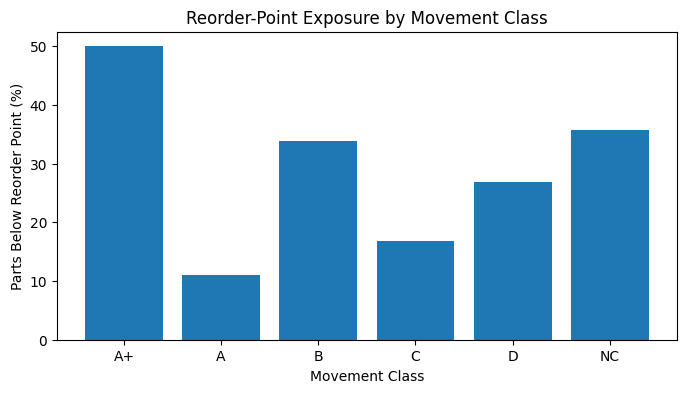

,Movement_Class,Parts,Below_Reorder_Point,Suggested_Replenishment_Qty,Suggested_Replenishment_Value_EUR,Avg_Stock_Coverage_Weeks,Planner_Exceptions,Below_Reorder_Point_%
1,A+,8,4,64,2066.34,7.962129,4,50.000000
0,A,9,1,0,0.00,6.370673,0,11.111111
2,B,59,20,135,1490.50,14.671524,13,33.898305
3,C,167,28,41,960.03,29.840836,8,16.766467
4,D,338,91,35,2913.52,76.378099,11,26.923077
5,NC,419,150,28,7573.58,244.323010,11,35.799523


In [6]:
movement_replenishment = (
    replenishment
    .groupby("Movement_Class", dropna=False)
    .agg(
        Parts=("Part_ID", "count"),
        Below_Reorder_Point=("Below_Reorder_Point", "sum"),
        Suggested_Replenishment_Qty=("Suggested_Replenishment_Qty", "sum"),
        Suggested_Replenishment_Value_EUR=(
            "Suggested_Replenishment_Value_EUR",
            "sum"
        ),
        Avg_Stock_Coverage_Weeks=("Stock_Coverage_Weeks", "mean"),
        Planner_Exceptions=("Planner_Exception_Flag", "sum")
    )
    .reset_index()
)

movement_replenishment["Below_Reorder_Point_%"] = (
    movement_replenishment["Below_Reorder_Point"] /
    movement_replenishment["Parts"] * 100
)

movement_order = ["A+", "A", "B", "C", "D", "NC"]

movement_replenishment["Movement_Class"] = pd.Categorical(
    movement_replenishment["Movement_Class"],
    categories=movement_order,
    ordered=True
)

movement_replenishment = (
    movement_replenishment
    .sort_values("Movement_Class")
)

plt.figure(figsize=(8,4))

plt.bar(
    movement_replenishment["Movement_Class"].astype(str),
    movement_replenishment["Below_Reorder_Point_%"]
)

plt.xlabel("Movement Class")
plt.ylabel("Parts Below Reorder Point (%)")
plt.title("Reorder-Point Exposure by Movement Class")

plt.show()

movement_replenishment

## Purchase Requisition Workflow

Purchase requisitions represent the workflow output generated from replenishment triggers. This section reviews requisition workload by status, priority, reason code, and supplier.

In [7]:
purchase_requisition_detail = (
    purchase_requisitions
    .merge(
        part_master[[
            "Part_ID",
            "Part_Name",
            "Part_Category",
            "Movement_Class",
            "ABC_Class",
            "Criticality",
            "Unit_Cost_EUR"
        ]],
        on="Part_ID",
        how="left"
    )
    .merge(
        supplier_master[[
            "Supplier_ID",
            "Supplier_Name",
            "Supplier_Region",
            "Avg_Lead_Time_Days",
            "Reliability_Score"
        ]],
        on="Supplier_ID",
        how="left"
    )
)

purchase_requisition_detail.head()

,Purchase_Requisition_ID,Part_ID,Supplier_ID,Requested_Qty,Estimated_Value_EUR,Priority,Reason_Code,Status,Part_Name,Part_Category,Movement_Class,ABC_Class,Criticality,Unit_Cost_EUR,Supplier_Name,Supplier_Region,Avg_Lead_Time_Days,Reliability_Score
0,PR000001,VL-CON-0336,SUP-004,22,641.52,High,Below_Reorder_Point,Planner Review,Scissor Lift Air Filter,Consumables & service kits,A+,A,Medium,29.16,EU Industrial Components 04,EU,7,0.95
1,PR000002,TC-CON-0329,SUP-018,21,914.34,High,Below_Reorder_Point,Planner Review,A2024 LL Air Filter,Consumables & service kits,A+,A,Medium,43.54,EU Industrial Components 18,EU,9,0.83
2,PR000003,WA-CON-0631,SUP-020,13,350.48,High,Below_Reorder_Point,Planner Review,Exact Precision Lubrication Kit,Consumables & service kits,A+,A,Medium,26.96,EU Industrial Components 20,EU,9,0.98
3,PR000004,VL-CON-0419,SUP-020,8,160.00,High,Below_Reorder_Point,Planner Review,ERCO Lift O-Ring Kit,Consumables & service kits,A+,A,High,20.00,EU Industrial Components 20,EU,9,0.98
4,PR000005,AD-CON-0459,SUP-019,7,24.64,Medium,Below_Reorder_Point,Planner Review,Diagnostic Console Protective Cover,Consumables & service kits,B,C,Medium,3.52,EU Industrial Components 19,EU,4,0.89


In [8]:
pr_workload_summary = (
    purchase_requisition_detail
    .groupby(["Status", "Priority", "Reason_Code"], dropna=False)
    .agg(
        Purchase_Requisitions=("Purchase_Requisition_ID", "count"),
        Requested_Qty=("Requested_Qty", "sum"),
        Estimated_Value_EUR=("Estimated_Value_EUR", "sum"),
        Avg_Lead_Time_Days=("Avg_Lead_Time_Days", "mean"),
        Avg_Supplier_Reliability=("Reliability_Score", "mean")
    )
    .reset_index()
    .sort_values("Estimated_Value_EUR", ascending=False)
)

pr_workload_summary

,Status,Priority,Reason_Code,Purchase_Requisitions,Requested_Qty,Estimated_Value_EUR,Avg_Lead_Time_Days,Avg_Supplier_Reliability
1,Planner Review,Low,Below_Reorder_Point,27,91,7518.13,8.259259,0.891111
0,Planner Review,High,Below_Reorder_Point,7,77,5995.34,7.142857,0.908571
2,Planner Review,Medium,Below_Reorder_Point,13,135,1490.50,8.769231,0.848462


## Supplier Replenishment Exposure

Supplier-level aggregation identifies where replenishment workload, value exposure, and lead-time risk are concentrated.

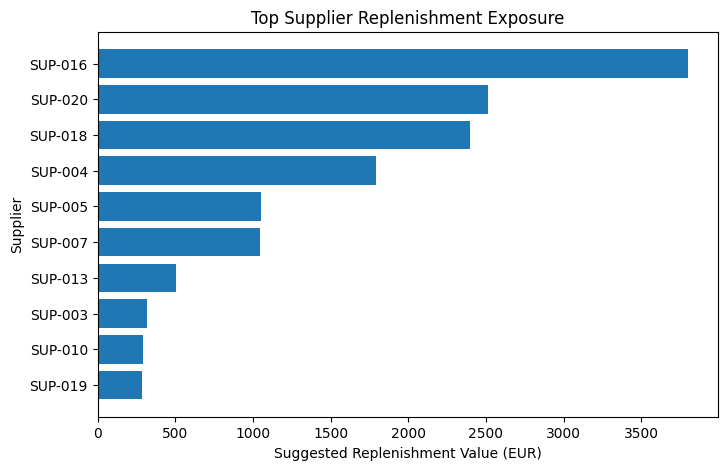

,Supplier_ID,Supplier_Name,Supplier_Region,Parts_To_Replenish,Suggested_Replenishment_Qty,Suggested_Replenishment_Value_EUR,Avg_Lead_Time_Days,Avg_Reliability_Score,Planner_Exceptions,Avg_Priority_Score
14,SUP-016,EU Industrial Components 16,EU,4,25,3802.14,8.0,0.86,4,11.64
18,SUP-020,EU Industrial Components 20,EU,5,28,2510.48,9.0,0.98,5,13.22
16,SUP-018,EU Industrial Components 18,EU,7,52,2397.43,9.0,0.83,7,13.17
3,SUP-004,EU Industrial Components 04,EU,5,33,1795.46,7.0,0.95,5,13.85
4,SUP-005,Eastern Europe Industrial Components 05,Eastern Europe,4,37,1050.00,10.0,0.75,4,13.25
6,SUP-007,Eastern Europe Industrial Components 07,Eastern Europe,2,14,1048.12,10.0,0.91,2,12.09
11,SUP-013,North America Industrial Components 13,North America,2,22,504.36,19.0,0.86,2,15.14
2,SUP-003,EU Industrial Components 03,EU,2,8,318.36,6.0,0.85,2,13.15
9,SUP-010,EU Industrial Components 10,EU,4,12,289.24,8.0,0.92,4,12.58
17,SUP-019,EU Industrial Components 19,EU,2,15,283.68,4.0,0.89,2,13.61


In [9]:
supplier_replenishment = (
    replenishment[replenishment["Suggested_Replenishment_Qty"] > 0]
    .groupby(["Supplier_ID", "Supplier_Name", "Supplier_Region"], dropna=False)
    .agg(
        Parts_To_Replenish=("Part_ID", "count"),
        Suggested_Replenishment_Qty=("Suggested_Replenishment_Qty", "sum"),
        Suggested_Replenishment_Value_EUR=("Suggested_Replenishment_Value_EUR", "sum"),
        Avg_Lead_Time_Days=("Avg_Lead_Time_Days", "mean"),
        Avg_Reliability_Score=("Reliability_Score", "mean"),
        Planner_Exceptions=("Planner_Exception_Flag", "sum"),
        Avg_Priority_Score=("Replenishment_Priority_Score", "mean")
    )
    .reset_index()
    .sort_values("Suggested_Replenishment_Value_EUR", ascending=False)
)

top_supplier_plot = supplier_replenishment.head(10).sort_values("Suggested_Replenishment_Value_EUR")

plt.figure(figsize=(8,5))

plt.barh(
    top_supplier_plot["Supplier_ID"],
    top_supplier_plot["Suggested_Replenishment_Value_EUR"]
)

plt.xlabel("Suggested Replenishment Value (EUR)")
plt.ylabel("Supplier")
plt.title("Top Supplier Replenishment Exposure")

plt.show()

supplier_replenishment.head(15)

## Planner Review Queue

The planner review queue highlights replenishment suggestions that combine low coverage, reorder-point exposure, high movement, or criticality. These are the records most likely to require operational action.

In [10]:
planner_review_queue = priority_review[[
    "Part_ID",
    "Part_Name",
    "Part_Category",
    "Movement_Class",
    "ABC_Class",
    "XYZ_Class",
    "Criticality",
    "Supplier_ID",
    "Supplier_Name",
    "Available_Qty",
    "On_Order_Qty",
    "Reorder_Point_Qty",
    "Suggested_Replenishment_Qty",
    "Suggested_Replenishment_Value_EUR",
    "Stock_Coverage_Weeks",
    "Lead_Time_Weeks",
    "Lead_Time_Coverage_Gap_Weeks",
    "Planner_Exception_Flag",
    "Replenishment_Priority_Score"
]].copy()

planner_review_queue.head(25)

,Part_ID,Part_Name,Part_Category,Movement_Class,ABC_Class,XYZ_Class,Criticality,Supplier_ID,Supplier_Name,Available_Qty,On_Order_Qty,Reorder_Point_Qty,Suggested_Replenishment_Qty,Suggested_Replenishment_Value_EUR,Stock_Coverage_Weeks,Lead_Time_Weeks,Lead_Time_Coverage_Gap_Weeks,Planner_Exception_Flag,Replenishment_Priority_Score
2,TC-CON-0329,A2024 LL Air Filter,Consumables & service kits,A+,A,X,Medium,SUP-018,EU Industrial Components 18,18,0,22,21,914.34,5.348571,1.3,-4.048571,True,17.17
1,VL-CON-0336,Scissor Lift Air Filter,Consumables & service kits,A+,A,X,Medium,SUP-004,EU Industrial Components 04,16,0,22,22,641.52,4.153078,1.0,-3.153078,True,17.05
19,AD-CON-0798,Radar Calibration Lubrication Kit,Consumables & service kits,B,A,Y,High,SUP-005,Eastern Europe Industrial Components 05,11,4,17,13,394.81,11.070968,1.4,-9.670968,True,16.25
50,VL-CON-0387,ERCO Lift Filter Kit,Consumables & service kits,B,C,Y,High,SUP-013,North America Industrial Components 13,14,6,23,19,84.36,10.653659,2.7,-7.953659,True,16.14
38,TC-CON-0347,A2024 LL Protective Cover,Consumables & service kits,B,A,Z,Medium,SUP-014,Eastern Europe Industrial Components 14,12,3,16,11,208.34,26.742857,1.6,-25.142857,True,15.22
33,VL-CON-0279,Two-Post Lift Rubber Pad,Consumables & service kits,B,C,Y,Medium,SUP-018,EU Industrial Components 18,10,0,11,9,20.52,9.341317,1.3,-8.041317,True,15.17
18,WA-CON-0241,Exact Precision Filter Kit,Consumables & service kits,B,C,Y,Medium,SUP-001,Italy Industrial Components 01,8,3,11,7,32.90,9.454545,1.0,-8.454545,True,15.14
31,TC-CON-0491,HD1200 Truck Protective Cover,Consumables & service kits,B,C,Y,Medium,SUP-016,EU Industrial Components 16,6,0,10,8,21.60,5.379310,1.1,-4.279310,True,15.14
17,AD-CON-0459,Diagnostic Console Protective Cover,Consumables & service kits,B,C,Y,Medium,SUP-019,EU Industrial Components 19,7,0,8,7,24.64,4.986301,1.0,-3.986301,True,15.11
6,VL-CON-0419,ERCO Lift O-Ring Kit,Consumables & service kits,A+,A,Y,High,SUP-020,EU Industrial Components 20,18,8,19,8,160.00,7.508021,1.3,-6.208021,True,15.02


In [ ]:
workflow_summary.to_csv(
    OUTPUT_DIR / "replenishment_workflow_summary.csv",
    index=False
)

movement_replenishment.to_csv(
    OUTPUT_DIR / "replenishment_by_movement_class.csv",
    index=False
)

pr_workload_summary.to_csv(
    OUTPUT_DIR / "purchase_requisition_workload_summary.csv",
    index=False
)

supplier_replenishment.to_csv(
    OUTPUT_DIR / "supplier_replenishment_exposure.csv",
    index=False
)

planner_review_queue.to_csv(
    OUTPUT_DIR / "planner_review_queue.csv",
    index=False
)

## Replenishment Workflow Interpretation

The replenishment workflow analysis connects stock-position monitoring with replenishment recommendations and purchase requisition review.

Key operational uses:
- identify parts requiring review before stock coverage falls below lead-time exposure
- prioritise planner workload by movement class, criticality, and supplier reliability
- monitor purchase requisition workload and estimated value exposure
- support ERP/WMS-style exception management for spare-parts availability
- evaluate replenishment sensitivity across different inventory segments